
# Netflix Recommendation System using Collaborative Filtering & SVD

## Project Overview
This project builds a personalized movie recommendation system inspired by Netflix. The objective is to recommend relevant movies to users based on historical rating behavior using Collaborative Filtering techniques.

### Business Problem
Streaming platforms need to deliver personalized recommendations to increase user engagement, retention, and watch time. This project demonstrates how machine learning can be used to recommend movies that align with a user's preferences.

### Project Objectives
- Analyze user-movie rating data
- Build a recommendation engine using Collaborative Filtering
- Implement Singular Value Decomposition (SVD)
- Evaluate recommendation quality using RMSE
- Generate personalized movie recommendations

### Skills Demonstrated
- Recommendation Systems
- Collaborative Filtering
- Matrix Factorization
- Singular Value Decomposition (SVD)
- Data Cleaning & Preprocessing
- Model Evaluation
- Python, Pandas, NumPy, Surprise Library

### Technologies Used
Python, Pandas, NumPy, Matplotlib, Seaborn, Scikit-Learn, Surprise

### Project Workflow
1. Business Understanding
2. Data Understanding
3. Data Preprocessing
4. Exploratory Data Analysis
5. Recommendation Model Development
6. SVD Model Training
7. Model Evaluation (RMSE)
8. Personalized Recommendations
9. Business Insights & Conclusion


# Netflix Recommendation System (Intellipaat Final Project)

This project is implemented as part of my Data Science learning journey. The goal is to build a recommendation system similar to Netflix using collaborative filtering techniques.

##  1. Business Understanding
- Objective: Recommend movies to users
- Why: Improve user engagement and watch time
- Approach: Collaborative Filtering (User-Item interactions)

## 2. Data Understanding
The dataset contains:
- Cust_Id → User ID
- Movie_Id → Movie ID
- Rating → User rating (1–5)

Insight: This forms a sparse matrix where most users rate only few movies.

##  3. Data Preprocessing
Key Steps:
- Handle missing values
- Assign correct Movie IDs
- Remove noise (inactive users)

## 4. Model Building
We use SVD (Matrix Factorization):
- Captures hidden patterns in user preferences
- Works well for sparse data

Why SVD?
It decomposes the user-item matrix into latent features.

##  5. Model Evaluation
- Metric: RMSE (Root Mean Squared Error)
- Lower RMSE → Better predictions

## 6. Recommendation System
Custom function to recommend top-N movies based on predicted ratings.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive

# Drive link : https://drive.google.com/drive/folders/1SQ3XHOfBaLhh-X_8M9cHLOnmM8p79n8M

In [ ]:
!pip install numpy==1.26.4

In [ ]:
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Netflix/combinedNetflixData (2).txt", header = None, names =['Cust_Id', 'Rating'], usecols =[0,1])

In [ ]:
df

,Cust_Id,Rating
0,1:,NaN
1,1488844,3.0
2,822109,5.0
3,885013,4.0
4,30878,4.0
...,...,...
24058258,2591364,2.0
24058259,1791000,2.0
24058260,512536,5.0
24058261,988963,3.0


In [ ]:
# convert Rating column into float

df["Rating"] = df["Rating"].astype(float)

In [ ]:
df.dtypes

,0
Cust_Id,object
Rating,float64


In [ ]:
df.shape

(24058263, 2)

In [ ]:
df.columns

Index(['Cust_Id', 'Rating'], dtype='object')

In [ ]:
df.head()

,Cust_Id,Rating
0,1:,NaN
1,1488844,3.0
2,822109,5.0
3,885013,4.0
4,30878,4.0


In [ ]:
#To find the distribution of different ratings in the datset
Movie_Distribution = df.groupby('Rating')['Rating'].agg(['count'])

Movie_Distribution


,count
Rating,
1.0,1118186
2.0,2439073
3.0,6904181
4.0,8085741
5.0,5506583


In [ ]:
# get movie count by counting nan values

movie_count = df.isnull().sum()[1]

movie_count

#4499 total number of movies present in dataset

/tmp/ipykernel_30579/2648448105.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  movie_count = df.isnull().sum()[1]


4499

In [ ]:
# get customer count
cust_count = df['Cust_Id'].nunique()-movie_count

cust_count

470758

In [ ]:
# get rating count

rating_count = df['Cust_Id'].count() - movie_count

rating_count

24053764

## To plot the distribution of the ratings in as a bar plot

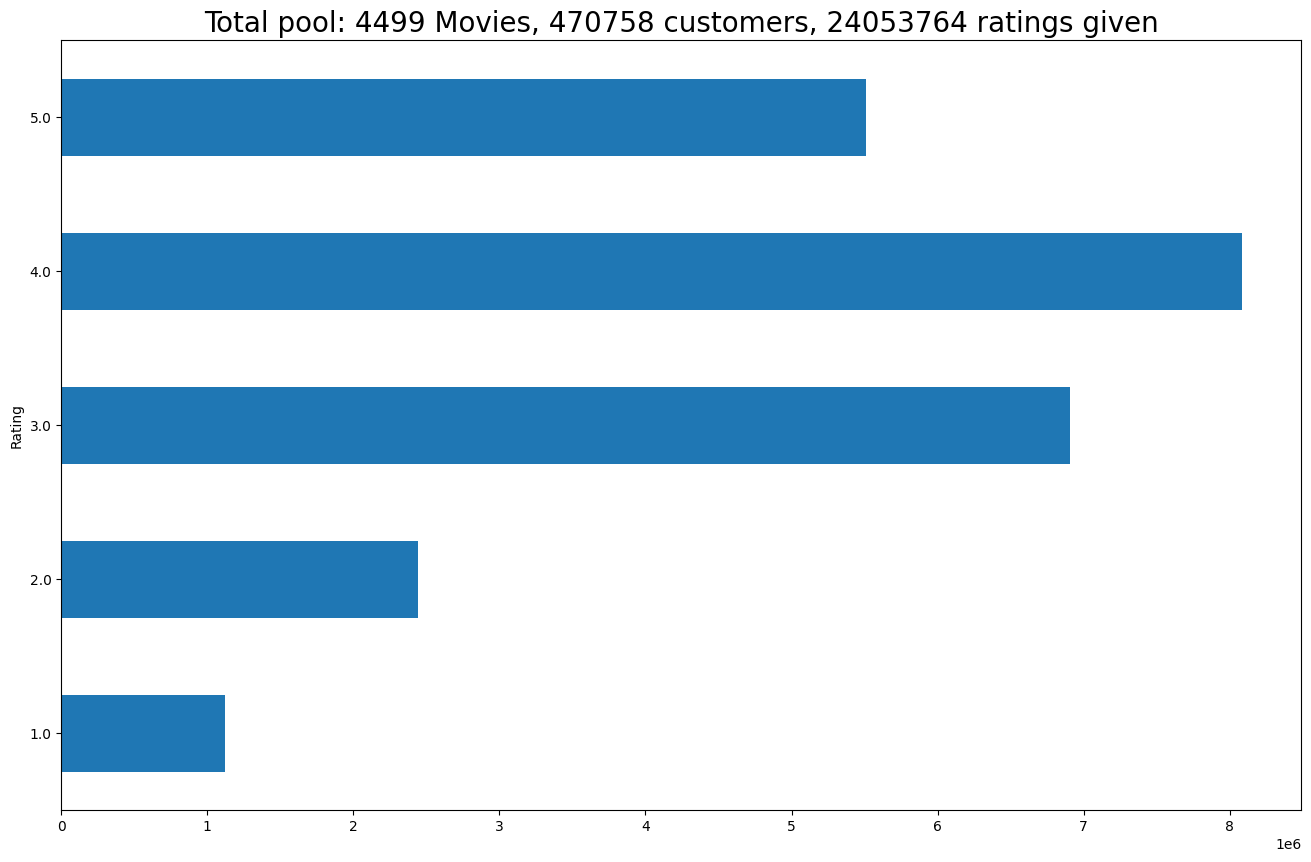

In [ ]:
import matplotlib.pyplot as plt

ax = Movie_Distribution.plot(kind = 'barh', legend = False, figsize = (16,10))
plt.title(f'Total pool: {movie_count} Movies, {cust_count} customers, {rating_count} ratings given', fontsize=20)
plt.show()

# To create a numpy array containing movie ids corresponding to the rows in the 'ratings' dataset

In [ ]:
# To count all the 'nan' values in the Ratings column in the 'ratings' dataset
df_nan = pd.DataFrame(pd.isnull(df.Rating))

df_nan.head()   # movie id : 1: - null

,Rating
0,True
1,False
2,False
3,False
4,False


In [ ]:
# To store the index of all the rows containing 'nan' values
df_nan = df_nan[df_nan['Rating'] == True]


df_nan.shape
# movie id


(4499, 1)

In [ ]:
df_nan # 0 to 547 - movie id :1

,Rating
0,True
548,True
694,True
2707,True
2850,True
...,...
24046714,True
24047329,True
24056849,True
24057564,True


In [ ]:
# To reset the index of the dataframe
df_nan = df_nan.reset_index()



df_nan.head()

,index,Rating
0,0,True
1,548,True
2,694,True
3,2707,True
4,2850,True


In [ ]:
df_nan['index'][:-1]

,index
0,0
1,548
2,694
3,2707
4,2850
...,...
4493,24046583
4494,24046714
4495,24047329
4496,24056849


In [ ]:
#To create a numpy array containing movie ids according the 'ratings' dataset

movie_np = []  # empty list
#movie_np = np.array([], dtype=int)
movie_id = 1
#into tuple
for i,j in zip(df_nan['index'][1:],df_nan['index'][:-1]):
    # numpy approach
    temp = np.full((1,i-j-1), movie_id)
    movie_np = np.append(movie_np, temp)
    movie_id += 1

# Account for last record and corresponding length
# numpy approach
last_record = np.full((1,len(df) - df_nan.iloc[-1, 0] - 1),movie_id)
movie_np = np.append(movie_np, last_record)

print(f'Movie numpy: {movie_np}')
print(f'Length: {len(movie_np)}')


Movie numpy: [1.000e+00 1.000e+00 1.000e+00 ... 4.499e+03 4.499e+03 4.499e+03]
Length: 24053764


In [ ]:
df_nan.iloc[-1, 0]

24057834

In [ ]:
len(df)

24058263

In [ ]:
#To append the above created array to the datset after removing the 'nan' rows
df = df[pd.notnull(df['Rating'])]#movies count so nan
df['Movie_Id'] = movie_np.astype(int)
df['Cust_Id'] =df['Cust_Id'].astype(int)
print('Dataset examples')
df.head()

/tmp/ipykernel_30579/2650027332.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Movie_Id'] = movie_np.astype(int)


Dataset examples


/tmp/ipykernel_30579/2650027332.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Cust_Id'] =df['Cust_Id'].astype(int)


,Cust_Id,Rating,Movie_Id
1,1488844,3.0,1
2,822109,5.0,1
3,885013,4.0,1
4,30878,4.0,1
5,823519,3.0,1


In [ ]:
df.tail()

,Cust_Id,Rating,Movie_Id
24058258,2591364,2.0,4499
24058259,1791000,2.0,4499
24058260,512536,5.0,4499
24058261,988963,3.0,4499
24058262,1704416,3.0,4499


In [ ]:
df.shape

(24053764, 3)

**Data Cleaning**

In [ ]:
cm = ['count','mean']
#count and mean

In [ ]:
#To create a list of all the movies rated less often(only include top 30% rated movies)
df_movie_summary = df.groupby('Movie_Id')['Rating'].agg(cm)

df_movie_summary.index = df_movie_summary.index.map(int)

# logic

movie_benchmark = round(df_movie_summary['count'].quantile(0.7),0)

drop_movie_list = df_movie_summary[df_movie_summary['count'] < movie_benchmark].index

print('Movie minimum times of review: {}'.format(movie_benchmark))

# minimum on one movie

Movie minimum times of review: 1799.0


In [ ]:
#To create a list of all the inactive users(users who rate less often)
df_cust_summary = df.groupby('Cust_Id')['Rating'].agg(cm) #mean and count of customer id
df_cust_summary.index = df_cust_summary.index.map(int) #integer format
cust_benchmark = round(df_cust_summary['count'].quantile(0.7),0)  # set
drop_cust_list = df_cust_summary[df_cust_summary['count'] < cust_benchmark].index
#                                           6                       <  5
#drop_cust_list[3,4]
print(f'Customer minimum times of review: {cust_benchmark}')

Customer minimum times of review: 52.0


In [ ]:
print(f'Original Shape: {df.shape}')

Original Shape: (24053764, 3)


In [ ]:
df = df[~df['Movie_Id'].isin(drop_movie_list)]
#in df --->in all movie ids------>if the whic ever  movies we put under drop list are present or not---
#if present drop /remove them
df = df[~df['Cust_Id'].isin(drop_cust_list)]
#removing all inactive users from our df
print('After Trim Shape: {}'.format(df.shape))

After Trim Shape: (17337458, 3)


In [ ]:
print('Data Examples')
df.head()

Data Examples


,Cust_Id,Rating,Movie_Id
696,712664,5.0,3
697,1331154,4.0,3
698,2632461,3.0,3
699,44937,5.0,3
700,656399,4.0,3


**Create ratings matrix for 'ratings' matrix with Rows = userId, Columns = movieId**

In [ ]:
df_p = pd.pivot_table(df,values='Rating',index='Cust_Id',columns='Movie_Id')

print(df_p.shape)

(143458, 1350)


In [ ]:
df_p.head()

Movie_Id,3,8,16,17,18,26,28,30,32,33,...,4472,4474,4478,4479,4485,4488,4490,4492,4493,4496
Cust_Id,,,,,,,,,,,,,,,,,,,,,
6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,NaN,NaN,...,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,5.0,NaN,NaN,NaN,NaN,4.0,5.0,NaN,NaN,...,3.0,NaN,NaN,5.0,NaN,NaN,NaN,NaN,NaN,NaN
79,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,NaN,NaN,...,4.0,NaN,NaN,NaN,NaN,NaN,4.0,NaN,NaN,NaN
97,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
134,NaN,NaN,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**To load the movie_titles dataset**

In [ ]:
df_title = pd.read_csv("/content/drive/MyDrive/Netflix/movie_titles.csv", encoding = "Latin-1", header = None, names = ['Movie_Id', 'Year', 'Name'], on_bad_lines='skip')

In [ ]:
df_title.set_index('Movie_Id', inplace = True)
df_title.head(10)

,Year,Name
Movie_Id,,
1,2003.0,Dinosaur Planet
2,2004.0,Isle of Man TT 2004 Review
3,1997.0,Character
4,1994.0,Paula Abdul's Get Up & Dance
5,2004.0,The Rise and Fall of ECW
6,1997.0,Sick
7,1992.0,8 Man
8,2004.0,What the #$*! Do We Know!?
9,1991.0,Class of Nuke 'Em High 2


**To install the scikit-surprise library for implementing SVD**

In [ ]:
pip install scikit-surprise

In [ ]:
from surprise import Reader, Dataset, SVD
from surprise.model_selection import cross_validate

In [ ]:
# Load Reader
reader = Reader()

# Correct line (IMPORTANT FIX)
data = Dataset.load_from_df(df[['Cust_Id', 'Movie_Id', 'Rating']][:100000], reader)

# Use SVD algorithm
svd = SVD()

# Evaluate model
cross_validate(svd, data, measures=['RMSE', 'MAE'], cv=3, verbose=True)

Evaluating RMSE, MAE of algorithm SVD on 3 split(s).

                  Fold 1  Fold 2  Fold 3  Mean    Std     
RMSE (testset)    0.9964  1.0016  0.9950  0.9977  0.0028  
MAE (testset)     0.8087  0.8097  0.8051  0.8078  0.0020  
Fit time          1.50    2.62    5.24    3.12    1.57    
Test time         0.38    0.46    0.31    0.38    0.06    


{'test_rmse': array([0.99637201, 1.00155436, 0.99503028]),
 'test_mae': array([0.80871269, 0.80971305, 0.80507452]),
 'fit_time': (1.5005784034729004, 2.6217665672302246, 5.244728088378906),
 'test_time': (0.38013696670532227, 0.4610729217529297, 0.3052182197570801)}

In [ ]:
df.head()

,Cust_Id,Rating,Movie_Id
696,712664,5.0,3
697,1331154,4.0,3
698,2632461,3.0,3
699,44937,5.0,3
700,656399,4.0,3


**To find all the movies rated as 5 stars by user with userId = 1331154**

In [ ]:
df_1331154 = df[(df['Cust_Id'] == 1331154) & (df['Rating'] == 5)]
df_1331154 = df_1331154.set_index('Movie_Id')
df_1331154 = df_1331154.join(df_title)['Name']


df_1331154.head(10)

,Name
Movie_Id,
143,The Game
270,Sex and the City: Season 4
361,The Phantom of the Opera: Special Edition
457,Kill Bill: Vol. 2
482,Frida
658,Robin Hood: Prince of Thieves
763,The Poseidon Adventure
1144,Fried Green Tomatoes
1425,No Way Out


**Train an SVD to predict ratings for user with userId = 1**

In [ ]:
df_title

,Year,Name
Movie_Id,,
1,2003.0,Dinosaur Planet
2,2004.0,Isle of Man TT 2004 Review
3,1997.0,Character
4,1994.0,Paula Abdul's Get Up & Dance
5,2004.0,The Rise and Fall of ECW
...,...,...
17766,2002.0,Where the Wild Things Are and Other Maurice Se...
17767,2004.0,Fidel Castro: American Experience
17768,2000.0,Epoch


In [ ]:
# Create a shallow copy for the movies dataset
user_712664 = df_title.copy()

user_712664 = user_712664.reset_index()

#To remove all the movies rated less often
user_712664 = user_712664[~user_712664['Movie_Id'].isin(drop_movie_list)]


# getting full dataset
data = Dataset.load_from_df(df[['Cust_Id', 'Movie_Id', 'Rating']], reader)

#create a training set for svd
trainset = data.build_full_trainset()
svd.fit(trainset)

#Predict the ratings for user_712664
user_712664['Estimate_Score'] = user_712664['Movie_Id'].apply(lambda x: svd.predict(712664, x).est)

# estimated rating score

#Drop extra columns from the user_712664 data frame
user_712664 = user_712664.drop('Movie_Id', axis = 1)

# Sort predicted ratings for user_712664 in descending order
user_712664 = user_712664.sort_values('Estimate_Score', ascending=False)

#Print top 10 recommendations
print(user_712664.head(10))


        Year                            Name  Estimate_Score
857   1954.0                   Seven Samurai        5.000000
173   1992.0                  Reservoir Dogs        5.000000
711   2003.0              The Wire: Season 1        5.000000
4277  1996.0              Mr. Show: Season 2        4.996607
2067  1994.0          The Simpsons: Season 6        4.975896
4270  2002.0  Curb Your Enthusiasm: Season 3        4.952942
1786  1970.0                 Le Cercle Rouge        4.944986
2389  1979.0      Alien: Collector's Edition        4.921330
1597  1986.0     Aliens: Collector's Edition        4.910881
1659  1989.0                   Lonesome Dove        4.890171


**Conclusion**

In this project, we built a Netflix-style recommendation system using collaborative filtering. After preprocessing the data and handling sparsity, we applied the SVD algorithm to capture user preferences and predict ratings.

The model was evaluated using RMSE and was able to provide reasonable predictions. Finally, we developed a function to generate personalized movie recommendations for users.

This project highlights how recommendation systems can improve user engagement in real-world platforms like Netflix.